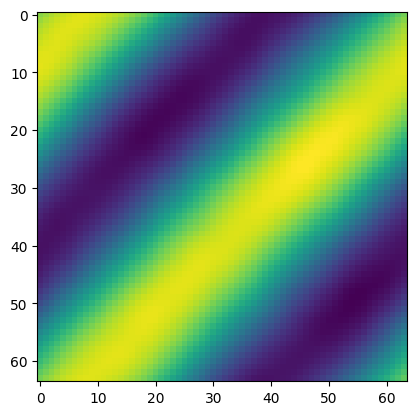

In [2]:
payload = torch.load("NS_data_zongyi_train_all_frame.pt", map_location="cpu", weights_only=False)
plt.imshow(payload["x"].mean(axis=0))

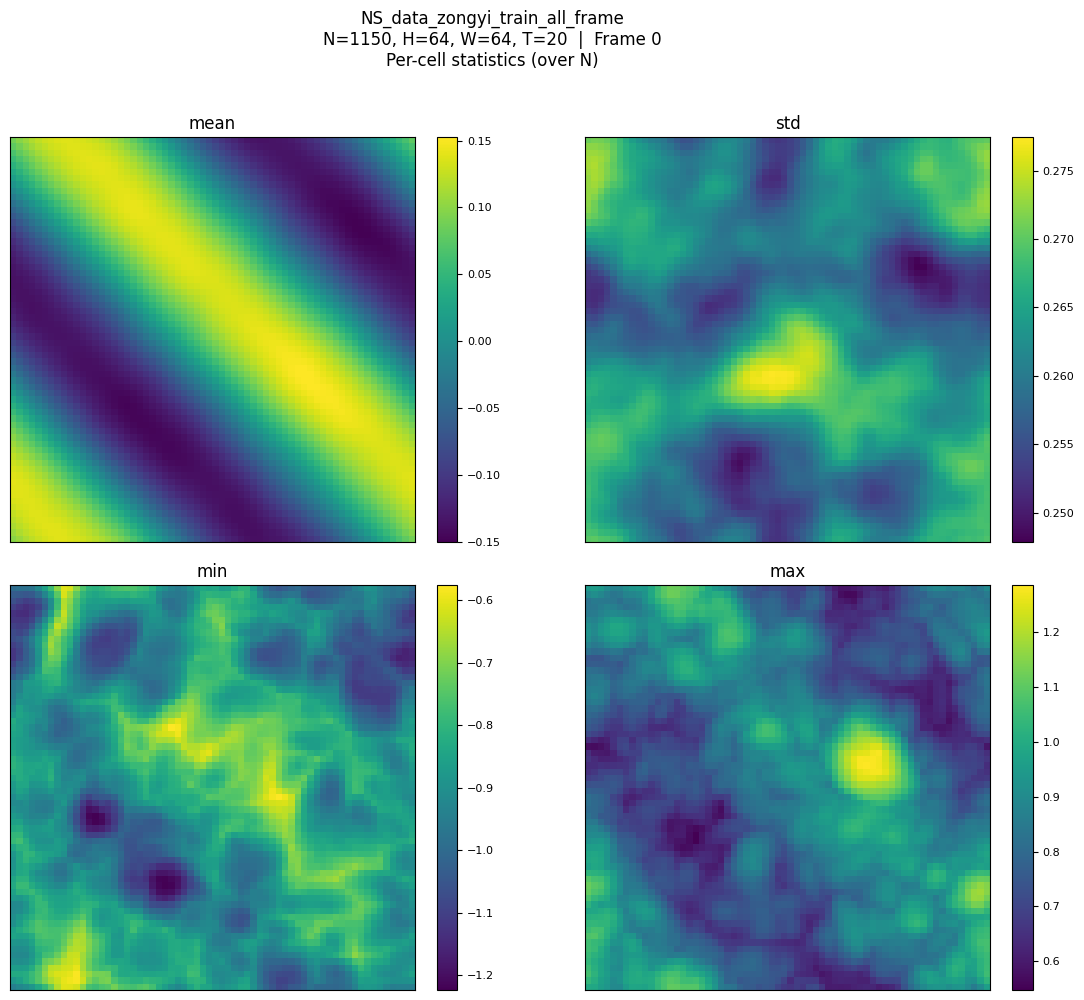

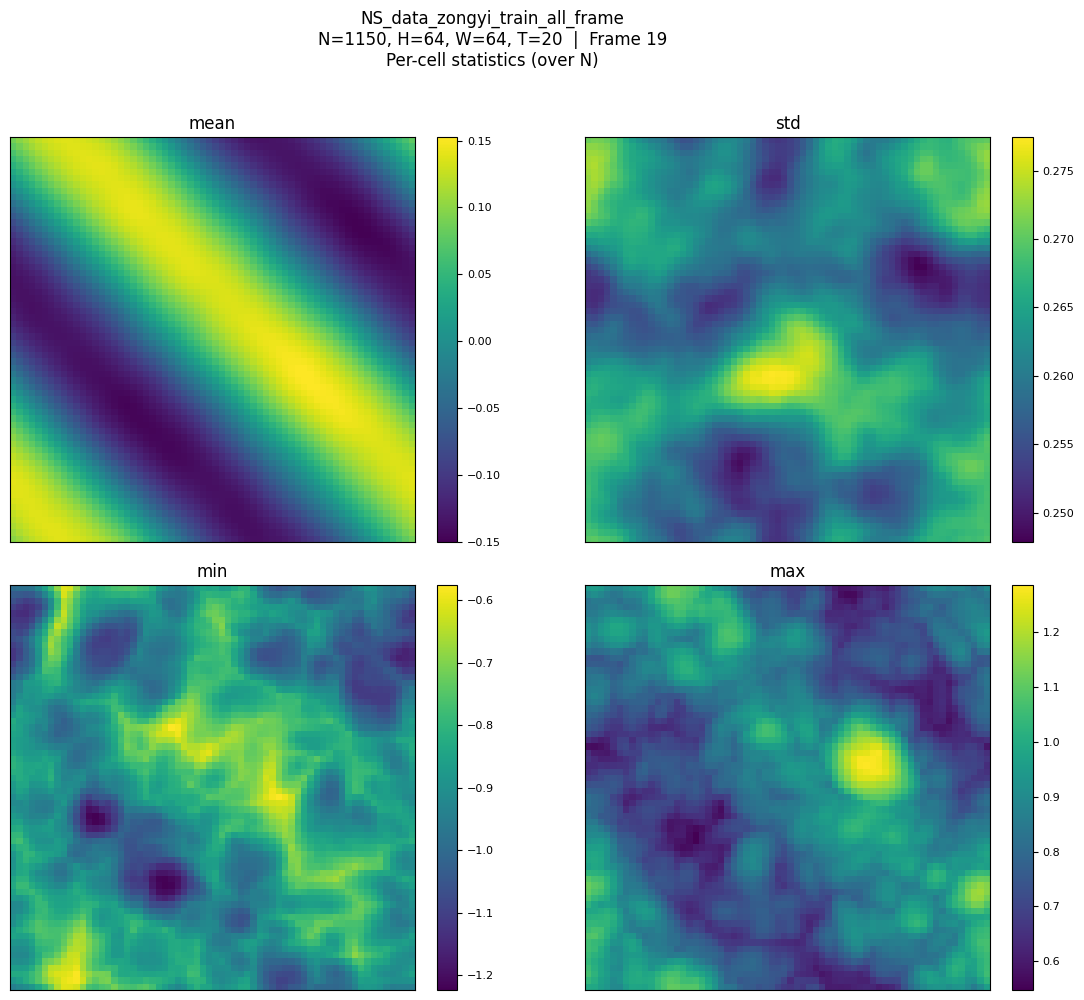

In [1]:
# ---- 在 notebook 里直接运行 ----
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

def _per_cell_stats_from_raw(y_t: torch.Tensor):
    """
    y_t: (N, H, W) torch tensor
    return: dict of HxW numpy arrays: mean, std, min, max
    统计维度是样本维 N（与之前脚本一致）。
    """
    if not torch.is_tensor(y_t) or y_t.ndim != 3:
        raise ValueError(f"expect y_t with shape (N,H,W), got {tuple(y_t.shape)}")
    # to numpy
    A = y_t.contiguous().cpu().numpy().astype(np.float64, copy=False)  # (N,H,W)
    N, H, W = A.shape
    A2D = A.reshape(N, H*W)  # (N, H*W)

    mean = np.nanmean(A2D, axis=0).reshape(H, W).astype(np.float32)
    std  = np.nanstd (A2D, axis=0).reshape(H, W).astype(np.float32)
    vmin = np.nanmin(A2D, axis=0).reshape(H, W).astype(np.float32)
    vmax = np.nanmax(A2D, axis=0).reshape(H, W).astype(np.float32)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax}

def _imshow2d(ax, arr, title):
    im = ax.imshow(arr, origin="lower", interpolation="nearest")
    ax.set_title(title, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

def show_spatial_percell_stats(pt_path, frames=(0,19)):
    """
    只需提供数据集路径 pt_path（.pt 文件，字典里含 'y' : (N,H,W,T)）。
    将分别“显示”两张图（frame0 和 frame19 各一张），不保存。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict) or "y" not in payload:
        raise ValueError(f"{pt_path.name}: not a dict or missing key 'y'")
    x = payload["x"]
    y = payload["y"]

    N, H, W, T = map(int, y.shape)
    stem = pt_path.stem

    for t in frames:
        if t < 0 or t >= T:
            print(f"[skip] frame {t} out of range 0..{T-1}")
            continue
        y_t = x[...]  # (N,H,W)
        stats = _per_cell_stats_from_raw(y_t)

        # 两行两列：mean / std / min / max
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        title_head = f"{stem}\nN={N}, H={H}, W={W}, T={T}  |  Frame {t}\nPer-cell statistics (over N)"
        fig.suptitle(title_head, y=0.995, fontsize=12)

        _imshow2d(axes[0,0], stats["mean"], "mean")
        _imshow2d(axes[0,1], stats["std"],  "std")
        _imshow2d(axes[1,0], stats["min"],  "min")
        _imshow2d(axes[1,1], stats["max"],  "max")

        fig.tight_layout(rect=[0,0,1,0.98])
        plt.show()

# 用法：把路径替换为你的 .pt 文件路径即可
show_spatial_percell_stats("NS_data_zongyi_train_all_frame.pt")


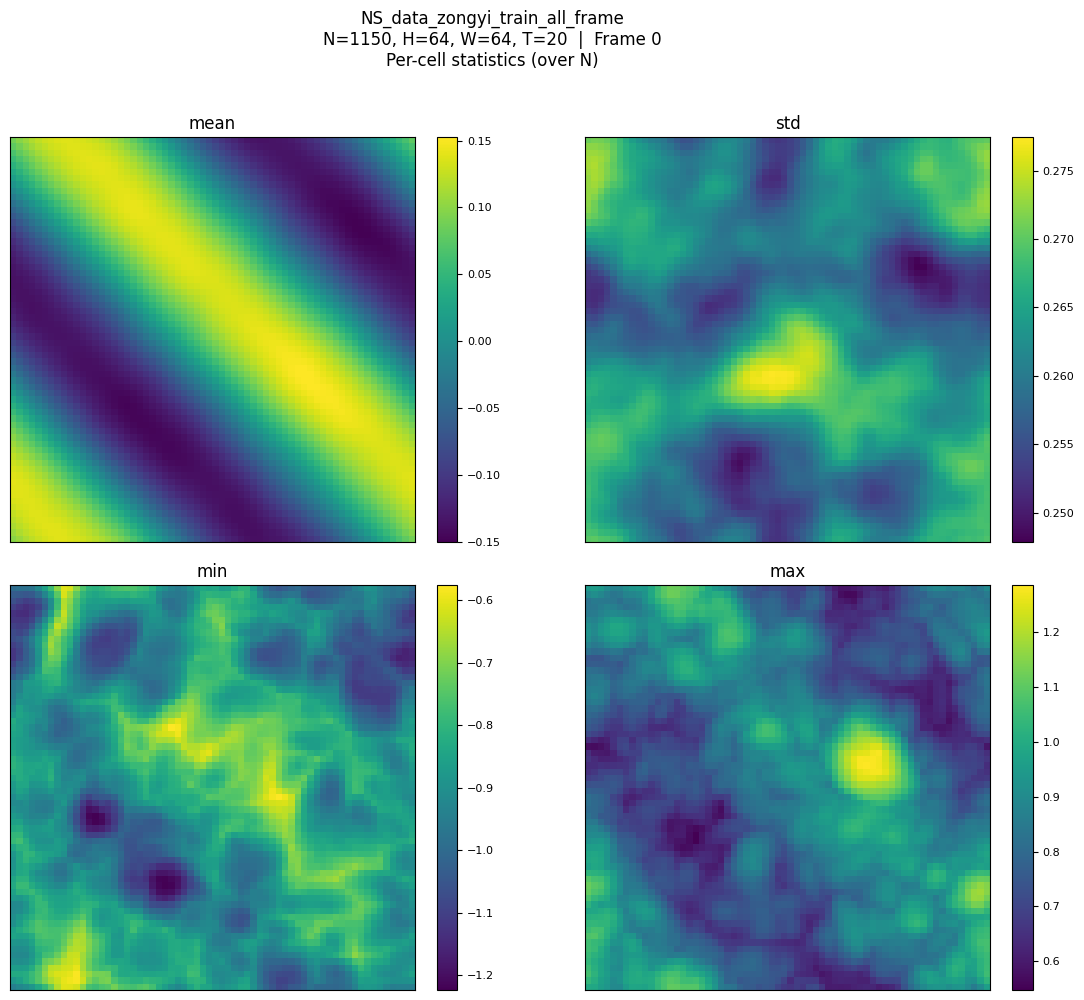

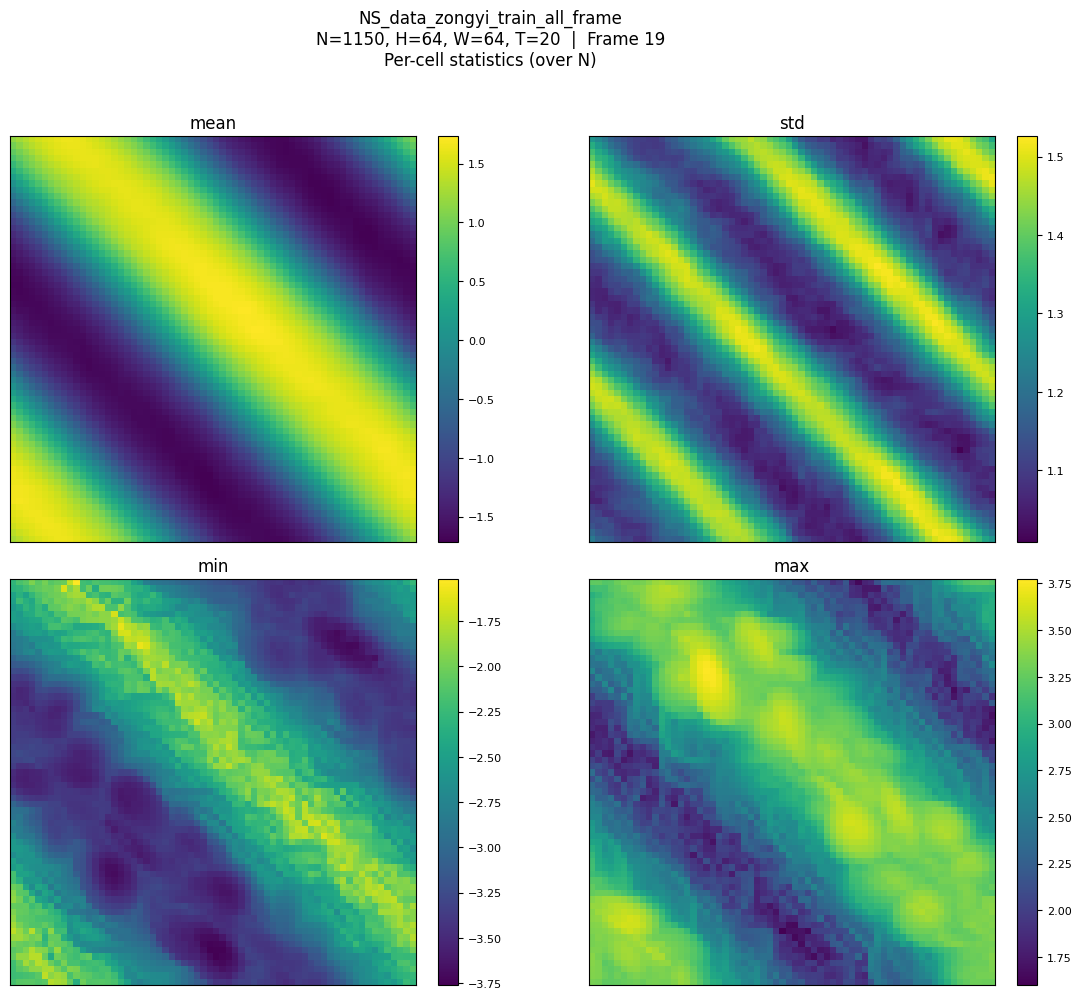

In [1]:
# ---- 在 notebook 里直接运行 ----
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

def _per_cell_stats_from_raw(y_t: torch.Tensor):
    """
    y_t: (N, H, W) torch tensor
    return: dict of HxW numpy arrays: mean, std, min, max
    统计维度是样本维 N（与之前脚本一致）。
    """
    if not torch.is_tensor(y_t) or y_t.ndim != 3:
        raise ValueError(f"expect y_t with shape (N,H,W), got {tuple(y_t.shape)}")
    # to numpy
    A = y_t.contiguous().cpu().numpy().astype(np.float64, copy=False)  # (N,H,W)
    N, H, W = A.shape
    A2D = A.reshape(N, H*W)  # (N, H*W)

    mean = np.nanmean(A2D, axis=0).reshape(H, W).astype(np.float32)
    std  = np.nanstd (A2D, axis=0).reshape(H, W).astype(np.float32)
    vmin = np.nanmin(A2D, axis=0).reshape(H, W).astype(np.float32)
    vmax = np.nanmax(A2D, axis=0).reshape(H, W).astype(np.float32)
    return {"mean": mean, "std": std, "min": vmin, "max": vmax}

def _imshow2d(ax, arr, title):
    im = ax.imshow(arr, origin="lower", interpolation="nearest")
    ax.set_title(title, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

def show_spatial_percell_stats(pt_path, frames=(0,19)):
    """
    只需提供数据集路径 pt_path（.pt 文件，字典里含 'y' : (N,H,W,T)）。
    将分别“显示”两张图（frame0 和 frame19 各一张），不保存。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    if not isinstance(payload, dict) or "y" not in payload:
        raise ValueError(f"{pt_path.name}: not a dict or missing key 'y'")
    y = payload["y"]
    if not torch.is_tensor(y) or y.ndim != 4:
        raise ValueError(f"{pt_path.name}: y should be (N,H,W,T), got {tuple(y.shape)}")
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    stem = pt_path.stem

    for t in frames:
        if t < 0 or t >= T:
            print(f"[skip] frame {t} out of range 0..{T-1}")
            continue
        y_t = y[..., t]  # (N,H,W)
        stats = _per_cell_stats_from_raw(y_t)

        # 两行两列：mean / std / min / max
        fig, axes = plt.subplots(2, 2, figsize=(12, 10))
        title_head = f"{stem}\nN={N}, H={H}, W={W}, T={T}  |  Frame {t}\nPer-cell statistics (over N)"
        fig.suptitle(title_head, y=0.995, fontsize=12)

        _imshow2d(axes[0,0], stats["mean"], "mean")
        _imshow2d(axes[0,1], stats["std"],  "std")
        _imshow2d(axes[1,0], stats["min"],  "min")
        _imshow2d(axes[1,1], stats["max"],  "max")

        fig.tight_layout(rect=[0,0,1,0.98])
        plt.show()

# 用法：把路径替换为你的 .pt 文件路径即可
show_spatial_percell_stats("NS_data_zongyi_train_all_frame.pt")


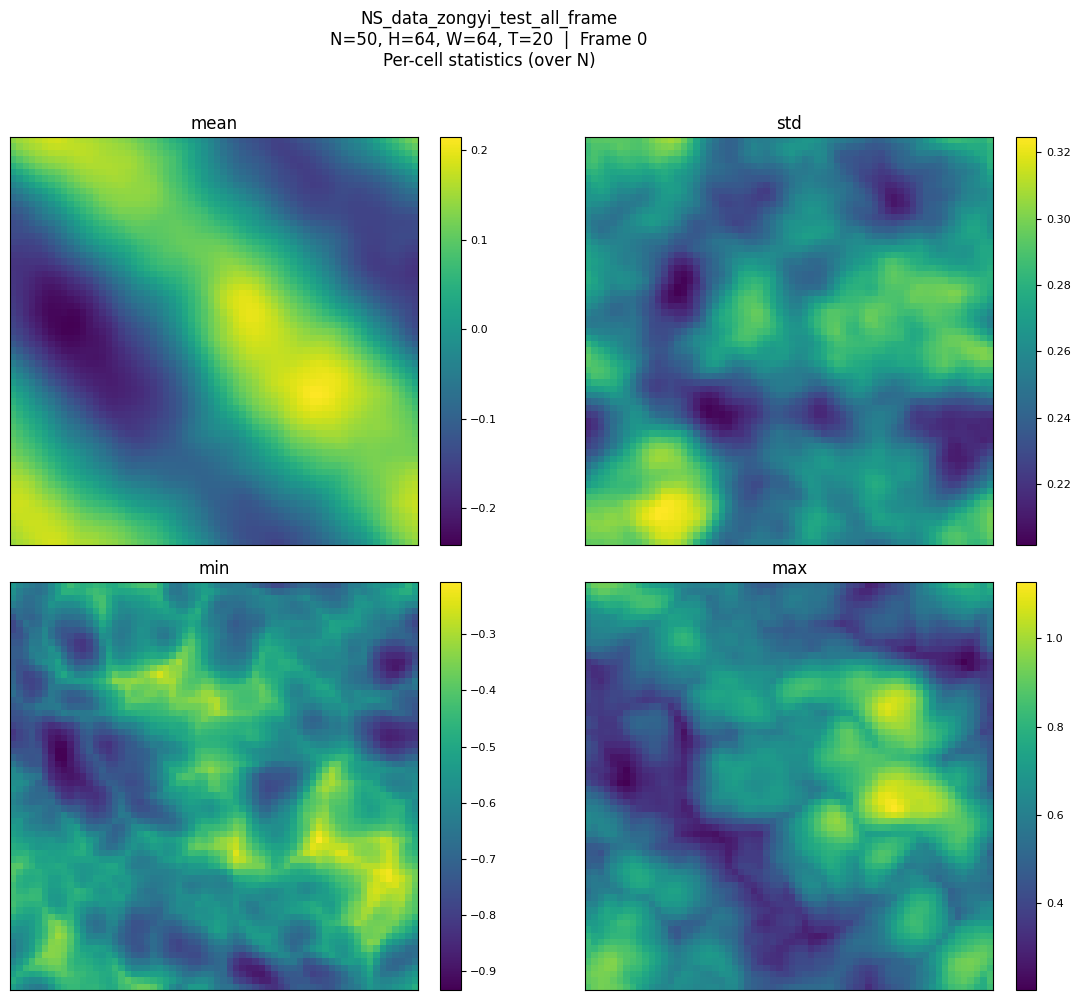

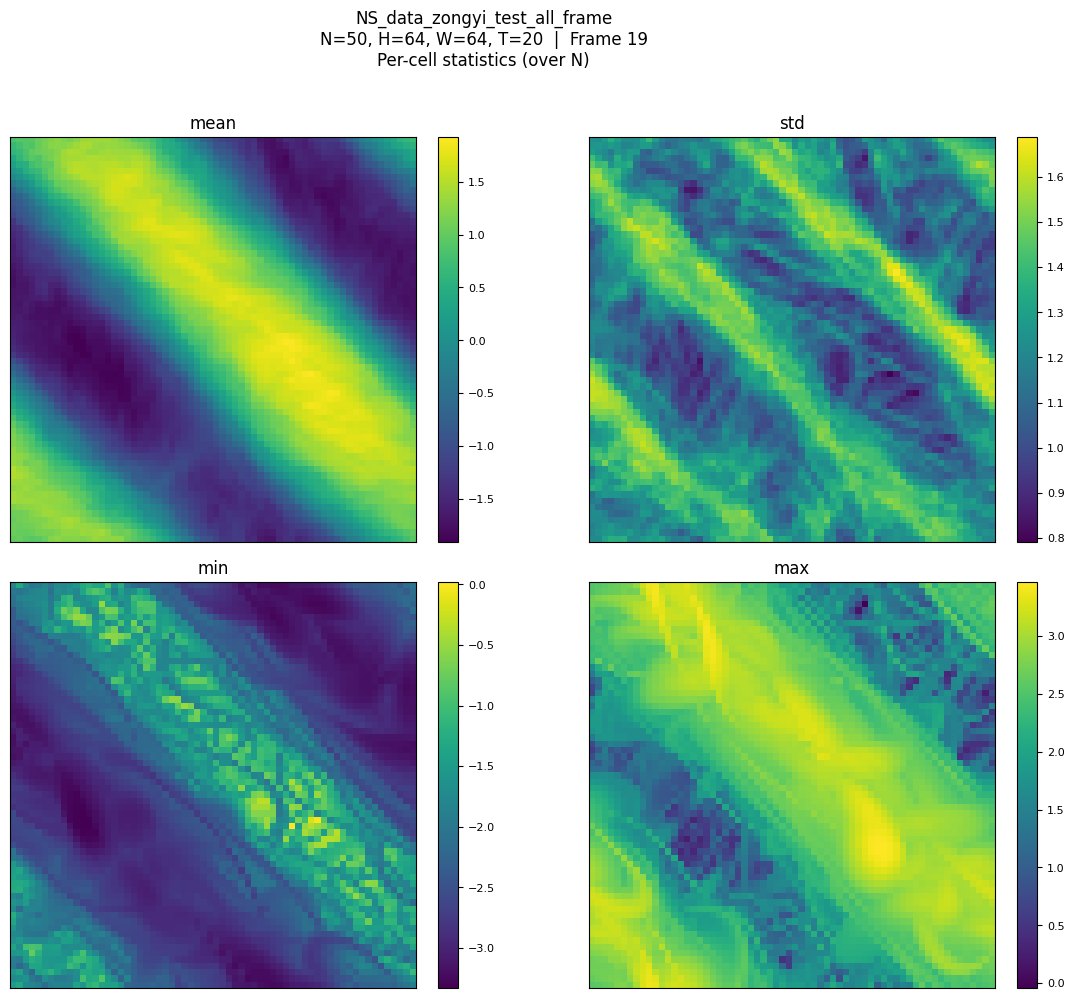

In [2]:
show_spatial_percell_stats("NS_data_zongyi_test_all_frame.pt")

In [3]:
test_dataset = torch.load("NS_data_zongyi_test_all_frame.pt", map_location="cpu", weights_only=False)

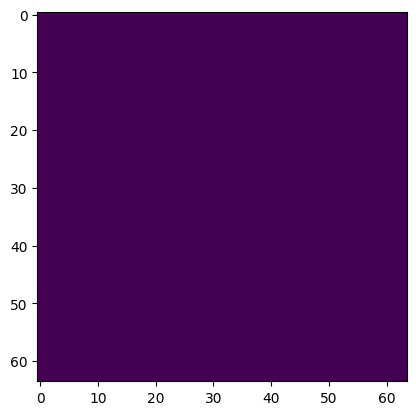

In [9]:
idx = 6
plt.imshow(test_dataset["x"][idx]-test_dataset["y"][idx][...,0])

In [7]:
test_dataset["x"][idx]-test_dataset["y"][idx][...,0]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [5]:
test_dataset["y"].shape

torch.Size([50, 64, 64, 20])

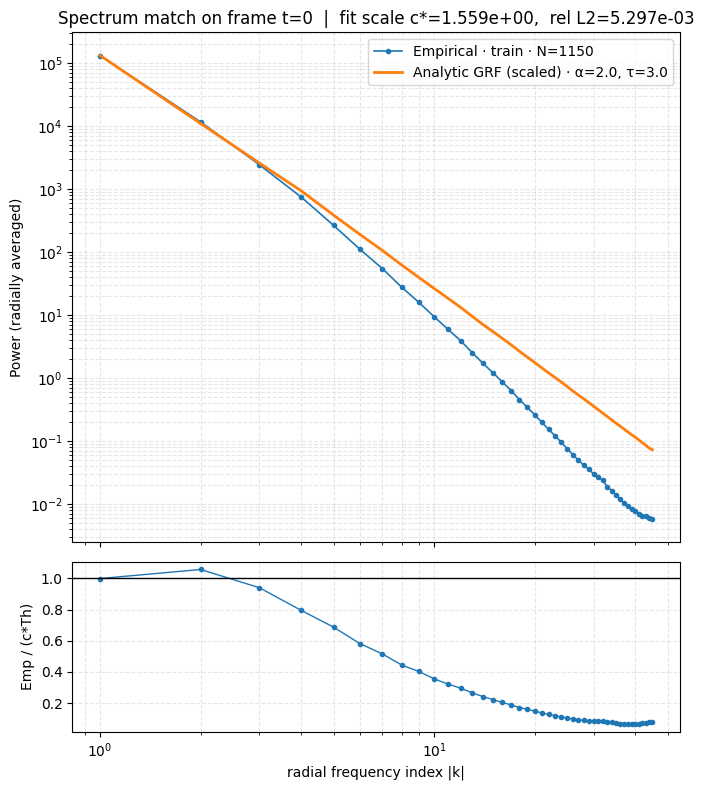

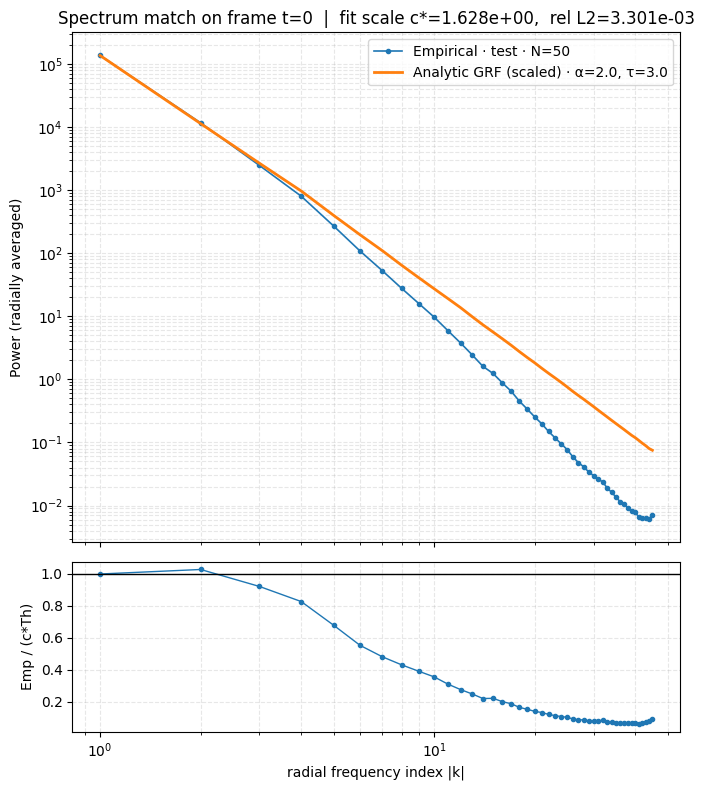

In [10]:
# %% imports
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# ========== 工具：构造与 GRF 一致的 k-网格、径向分箱索引 ==========
def _kgrid_and_bins(size: int, device="cpu"):
    """
    返回:
      kx, ky: (H,W) 整数波数网格 (未shift)
      ri_flat: (H*W,) 每个像元所在的整数半径分箱索引 floor(||k||)
      counts: (Rmax+1,) 每个半径分箱像元数量（单张平面）
    """
    H = W = size
    kmax = size // 2
    k1d = torch.cat((torch.arange(0, kmax, device=device),
                     torch.arange(-kmax, 0, device=device)), 0)
    kx = k1d.view(1, -1).repeat(H, 1)
    ky = k1d.view(-1, 1).repeat(1, W)

    r = torch.sqrt(kx.to(torch.float32)**2 + ky.to(torch.float32)**2)
    ri = torch.floor(r).to(torch.int64)                # 整数半径桶
    ri_flat = ri.reshape(-1)
    Rmax = int(ri_flat.max().item())
    counts = torch.bincount(ri_flat, minlength=Rmax+1).to(torch.float64)
    return kx, ky, ri_flat, counts

# ========== 经验功率谱（角向平均） ==========
@torch.no_grad()
def empirical_radial_psd_from_y0(y0: torch.Tensor, batch_size=64, device="cpu", fft_norm="backward"):
    """
    y0: (N, H, W)  第0帧的张量（float）
    返回:
      freq_k: (R,)  非负整数半径 k
      P_emp : (R,)  经验角向平均功率谱（已对像元计数与样本数做平均）
    """
    assert y0.ndim == 3, f"expect (N,H,W), got {tuple(y0.shape)}"
    N, H, W = map(int, y0.shape)
    assert H == W, "仅处理方阵"
    device = torch.device(device)

    # 预计算分箱
    _, _, ri_flat, counts_grid = _kgrid_and_bins(H, device=device)
    R = counts_grid.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)

    # 批处理累加
    left = N
    idx = 0
    while left > 0:
        b = min(batch_size, left)
        x = y0[idx:idx+b].to(device, non_blocking=True)            # (b,H,W)
        x = x - x.mean(dim=(-2,-1), keepdim=True)                  # 去 DC
        F = torch.fft.fft2(x, norm=fft_norm)                       # (b,H,W)
        P = (F.real**2 + F.imag**2).to(torch.float64)              # 功率

        # 把 b 个样本摊平成一条长向量做一次 scatter_add
        P_flat = P.reshape(-1)                                      # b*H*W
        ri_rep = ri_flat.repeat(b)                                  # b*H*W
        sums.scatter_add_(0, ri_rep, P_flat)
        idx += b
        left -= b

    # 对像元数与样本数取平均
    P_emp = sums / (counts_grid * N + 1e-12)
    freq_k = torch.arange(R, device=device)
    return freq_k.cpu().numpy(), P_emp.cpu().numpy()

# ========== 解析功率谱（由 GRF 的 sqrt_eig^2 得到） ==========
def analytic_radial_psd(size: int, alpha=2.0, tau=3.0, sigma=None, device="cpu"):
    """
    返回:
      freq_k: (R,), P_grf: (R,) —— 未做缩放拟合的“形状”曲线
    """
    device = torch.device(device)
    kx, ky, ri_flat, counts = _kgrid_and_bins(size, device=device)
    if sigma is None:
        sigma = tau**(0.5*(2*alpha - 2))  # dim=2

    # 与你类里一致的 sqrt_eig（dim=2）
    # 注意：这里只关心形状 -> 最后会做一档缩放拟合
    sqrt_eig = (size**2) * (np.sqrt(2.0)) * sigma * \
        (4*(np.pi**2)*(kx**2 + ky**2) + (tau**2))**(-alpha/2.0)
    sqrt_eig[0,0] = 0.0

    P_full = (sqrt_eig**2).to(torch.float64).reshape(-1)  # (H*W,)
    R = counts.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)
    sums.scatter_add_(0, ri_flat, P_full)
    P_grf = (sums / (counts + 1e-12)).cpu().numpy()
    freq_k = torch.arange(R).cpu().numpy()
    return freq_k, P_grf

# ========== 比对与画图 ==========
def compare_dataset_with_grf_spectrum(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    label=None
):
    """
    读取 pt -> 取 y[...,0] -> 经验谱 vs 解析谱（做一档缩放）并画图。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    if max_samples is not None and max_samples < N:
        N_use = int(max_samples)
        y0 = y[:N_use, :, :, 0].contiguous()
    else:
        N_use = N
        y0 = y[:, :, :, 0].contiguous()

    # 经验谱（角向平均）
    k_emp, P_emp = empirical_radial_psd_from_y0(y0, batch_size=batch_size, device=device, fft_norm=fft_norm)

    # 解析谱（由 sqrt_eig^2 的角向平均）
    k_th,  P_th_raw = analytic_radial_psd(H, alpha=alpha, tau=tau, sigma=sigma, device=device)
    if kmax is None:
        kmax = min(k_emp[-1], k_th[-1])

    # 对指定频段做“一档缩放”拟合
    m = (k_emp >= kmin) & (k_emp <= kmax)
    Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
    Pt = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe @ Pt) / (Pt @ Pt + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 计算一个简单的一致性指标（拟合段的相对 L2 误差）
    rel_l2 = torch.linalg.norm(Pe - c_star*Pt) / (torch.linalg.norm(Pe) + 1e-12)
    label = label or pt_path.stem

    # 画图：loglog + 比值
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                                   gridspec_kw={"height_ratios":[3,1]})
    ax1.loglog(k_emp[m], P_emp[m], 'o-', ms=3, lw=1.2, label=f"Empirical · {label} · N={N_use}")
    ax1.loglog(k_th[m],  P_th [m],  '-',  lw=2.0, label=f"Analytic GRF (scaled) · α={alpha}, τ={tau}")
    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')
    ax1.set_title(f"Spectrum match on frame t=0  |  fit scale c*={c_star.item():.3e},  rel L2={rel_l2.item():.3e}")

    ratio = (P_emp[m] / (P_th[m] + 1e-30))
    ax2.semilogx(k_emp[m], ratio, 'o-', ms=3, lw=1.0)
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "k": k_emp,                 # 全频段
        "P_emp": P_emp,
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2": float(rel_l2.item()),
        "N_used": N_use,
        "size": H,
    }

# ================= 示例调用 =================
# 把路径换成你的文件；alpha/tau 用你期望验证的 GRF 参数
# 你可以跑两次：train / test 各画一张图
res_train = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_train_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

res_test = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_test_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,
    batch_size=64,
    device="cpu",
    kmin=1, kmax=None,
    fft_norm="backward",
    label="test"
)


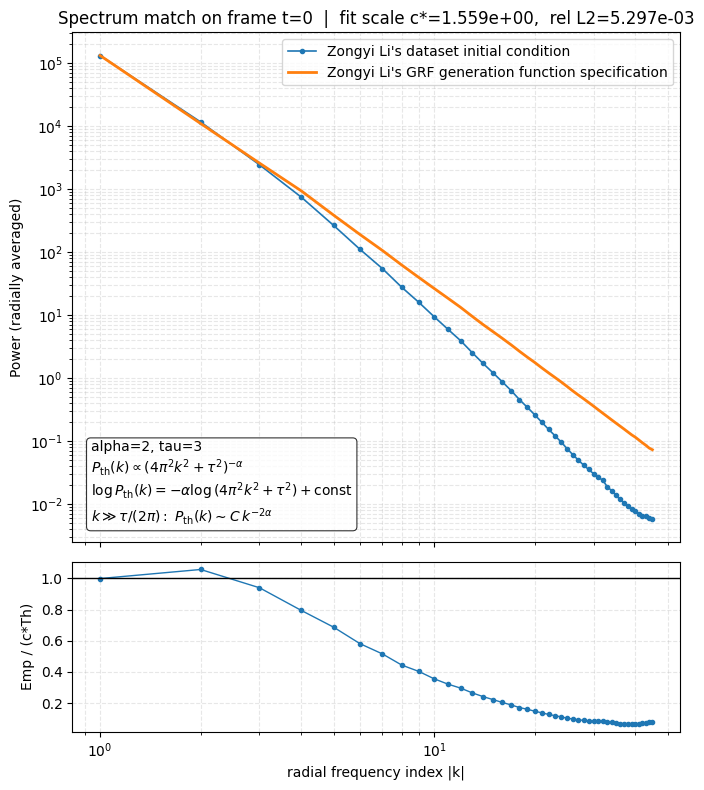

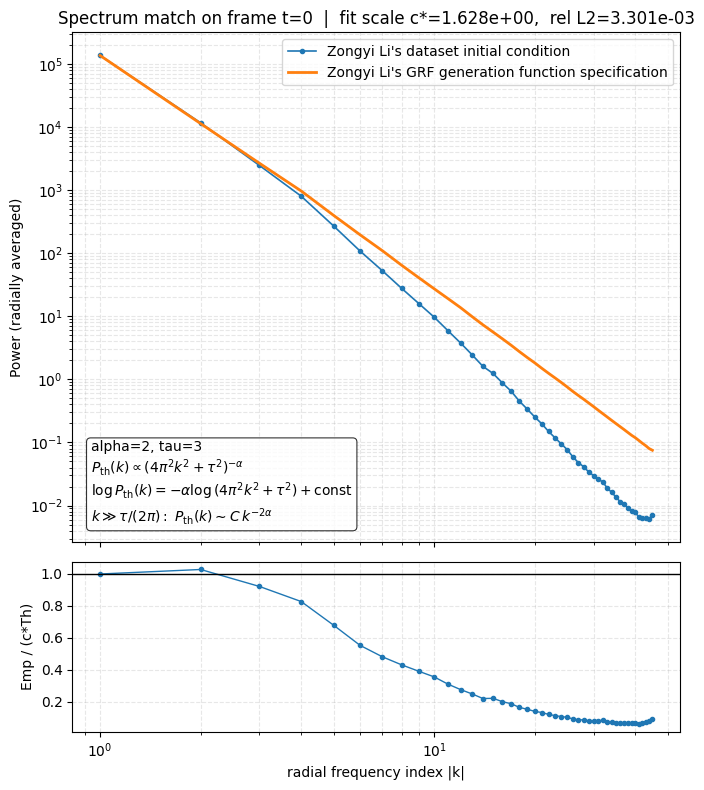

In [12]:
def compare_dataset_with_grf_spectrum(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    label=None
):
    """
    读取 pt -> 取 y[...,0] -> 经验谱 vs 解析谱（做一档缩放）并画图。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)
    if max_samples is not None and max_samples < N:
        N_use = int(max_samples)
        y0 = y[:N_use, :, :, 0].contiguous()
    else:
        N_use = N
        y0 = y[:, :, :, 0].contiguous()

    # 经验谱（角向平均）
    k_emp, P_emp = empirical_radial_psd_from_y0(
        y0, batch_size=batch_size, device=device, fft_norm=fft_norm
    )

    # 解析谱（由 sqrt_eig^2 的角向平均）
    k_th,  P_th_raw = analytic_radial_psd(
        H, alpha=alpha, tau=tau, sigma=sigma, device=device
    )
    if kmax is None:
        kmax = min(k_emp[-1], k_th[-1])

    # 对指定频段做“一档缩放”拟合
    m = (k_emp >= kmin) & (k_emp <= kmax)
    Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
    Pt = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe @ Pt) / (Pt @ Pt + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 简单一致性指标（拟合段相对 L2 误差）
    rel_l2 = torch.linalg.norm(Pe - c_star*Pt) / (torch.linalg.norm(Pe) + 1e-12)

    # ----- 画图：loglog + 比值，并按你的需求自定义 legend -----
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(7, 8), sharex=True, gridspec_kw={"height_ratios":[3,1]}
    )

    emp_label = "Zongyi Li's dataset initial condition"
    th_label  = "Zongyi Li's GRF generation function specification"

    ax1.loglog(k_emp[m], P_emp[m], 'o-', ms=3, lw=1.2, label=emp_label)
    ax1.loglog(k_th[m],  P_th [m],  '-',  lw=2.0, label=th_label)

    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')

    ax1.set_title(
        f"Spectrum match on frame t=0  |  fit scale c*={c_star.item():.3e},  rel L2={rel_l2.item():.3e}"
    )

    # —— 在图上标注理论公式与 log–log 形式（mathtext 兼容版）——
    # P_th(k) ∝ (4π^2 k^2 + τ^2)^(-α)
    # log P_th(k) = -α log(4π^2 k^2 + τ^2) + const
    # k >> τ/(2π): P_th(k) ~ C k^{-2α}
    eq1 = r"$P_{\mathrm{th}}(k)\propto\left(4\pi^{2}k^{2}+\tau^{2}\right)^{-\alpha}$"
    eq2 = r"$\log P_{\mathrm{th}}(k)=-\alpha\log\left(4\pi^{2}k^{2}+\tau^{2}\right)+\mathrm{const}$"
    eq3 = r"$k\gg\tau/(2\pi):\ P_{\mathrm{th}}(k)\sim C\,k^{-2\alpha}$"
    param_str = f"alpha={alpha:.3g}, tau={tau:.3g}"

    txt = param_str + "\n" + eq1 + "\n" + eq2 + "\n" + eq3
    ax1.text(
        0.03, 0.03, txt,
        transform=ax1.transAxes, ha='left', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, lw=0.8)
    )

    # 比值图
    ratio = (P_emp[m] / (P_th[m] + 1e-30))
    ax2.semilogx(k_emp[m], ratio, 'o-', ms=3, lw=1.0)
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "k": k_emp,
        "P_emp": P_emp,
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2": float(rel_l2.item()),
        "N_used": N_use,
        "size": H,
    }


# ================= 示例调用 =================
# 把路径换成你的文件；alpha/tau 用你期望验证的 GRF 参数
# 你可以跑两次：train / test 各画一张图
res_train = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_train_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

res_test = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_test_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,
    batch_size=64,
    device="cpu",
    kmin=1, kmax=None,
    fft_norm="backward",
    label="test"
)

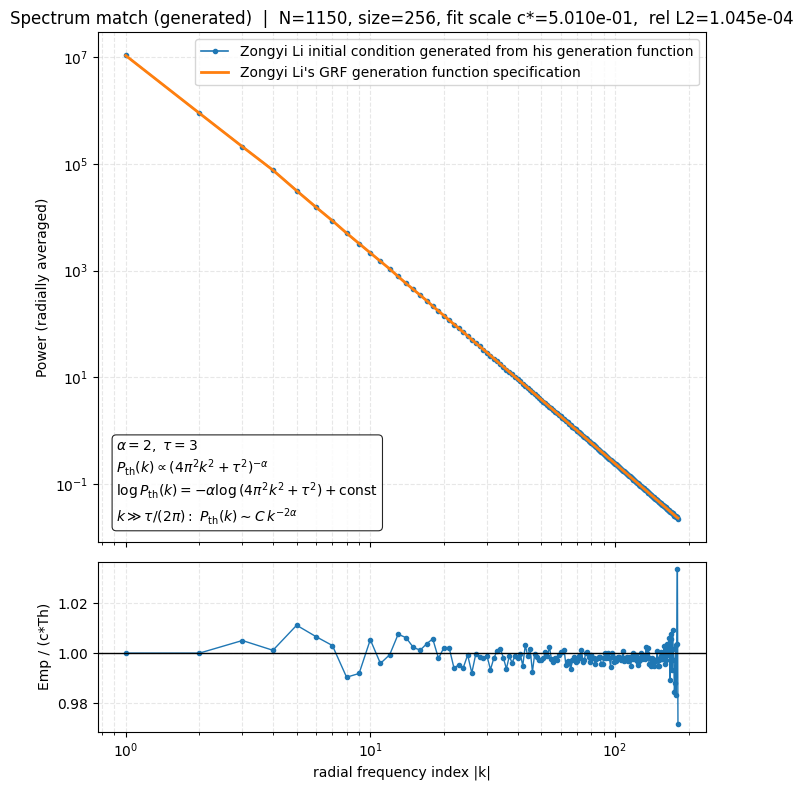

In [14]:
# -*- coding: utf-8 -*-
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt

# ===================== 你的 GRF 类（原样保留） =====================
import math
class GaussianRF(object):
    def __init__(self, dim, size, alpha=2, tau=3, sigma=None, boundary="periodic", device=None):
        self.dim = dim
        self.device = device
        if sigma is None:
            sigma = tau**(0.5*(2*alpha - self.dim))
        k_max = size//2

        if dim == 1:
            k = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                           torch.arange(start=-k_max, end=0, step=1, device=device)), 0)
            self.sqrt_eig = size*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0] = 0.0

        elif dim == 2:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,1)
            k_x = wavenumers.transpose(0,1)
            k_y = wavenumers
            self.sqrt_eig = (size**2)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0] = 0.0

        elif dim == 3:
            wavenumers = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                                    torch.arange(start=-k_max, end=0, step=1, device=device)), 0).repeat(size,size,1)
            k_x = wavenumers.transpose(1,2)
            k_y = wavenumers
            k_z = wavenumers.transpose(0,2)
            self.sqrt_eig = (size**3)*math.sqrt(2.0)*sigma*((4*(math.pi**2)*(k_x**2 + k_y**2 + k_z**2) + tau**2)**(-alpha/2.0))
            self.sqrt_eig[0,0,0] = 0.0

        self.size = tuple([size]*self.dim)

    def sample(self, N):
        coeff = torch.randn(N, *self.size, dtype=torch.cfloat, device=self.device)
        coeff = self.sqrt_eig * coeff
        return torch.fft.ifftn(coeff, dim=list(range(-1, -self.dim - 1, -1))).real


# ===================== 频率网格 & 径向分箱 =====================
def _kgrid_and_bins(size: int, device="cpu"):
    """
    返回:
      kx, ky: (H,W) 整数波数网格 (未shift)
      ri_flat: (H*W,) 每个像元的整数半径桶 floor(||k||)
      counts: (Rmax+1,) 每个半径桶的像元数量
    """
    H = W = size
    kmax = size // 2
    k1d = torch.cat((torch.arange(0, kmax, device=device),
                     torch.arange(-kmax, 0, device=device)), 0)
    kx = k1d.view(1, -1).repeat(H, 1)
    ky = k1d.view(-1, 1).repeat(1, W)
    r = torch.sqrt(kx.to(torch.float32)**2 + ky.to(torch.float32)**2)
    ri = torch.floor(r).to(torch.int64)
    ri_flat = ri.reshape(-1)
    Rmax = int(ri_flat.max().item())
    counts = torch.bincount(ri_flat, minlength=Rmax+1).to(torch.float64)
    return kx, ky, ri_flat, counts


# ===================== 经验谱：用采样器累加（省内存） =====================
@torch.no_grad()
def empirical_radial_psd_from_sampler(grf: GaussianRF, N: int, batch_size=64, device="cpu", fft_norm="backward"):
    """
    直接调用 GRF 采样器分批生成 (b,H,W)，对每批：
      - 每张去均值
      - FFT -> 功率
      - 径向分箱累加
    最后对像元数与样本数做平均。
    返回:
      freq_k: (R,), P_emp: (R,)
    """
    assert grf.dim == 2, "这里只处理 2D"
    H = W = grf.size[0]
    device = torch.device(device)

    # 预计算分箱
    _, _, ri_flat, counts_grid = _kgrid_and_bins(H, device=device)
    R = counts_grid.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)

    left = N
    while left > 0:
        b = min(batch_size, left)
        x = grf.sample(b)                              # (b,H,W), on grf.device
        x = x.to(device, non_blocking=True)
        x = x - x.mean(dim=(-2,-1), keepdim=True)      # 去 DC
        F = torch.fft.fft2(x, norm=fft_norm)
        P = (F.real**2 + F.imag**2).to(torch.float64)  # (b,H,W)

        P_flat = P.reshape(-1)                         # b*H*W
        ri_rep = ri_flat.repeat(b)
        sums.scatter_add_(0, ri_rep, P_flat)

        left -= b

    P_emp = sums / (counts_grid * N + 1e-12)
    freq_k = torch.arange(R, device=device)
    return freq_k.cpu().numpy(), P_emp.cpu().numpy()


# ===================== 解析谱：由 sqrt_eig^2 的径向平均 =====================
def analytic_radial_psd(size: int, alpha=2.0, tau=3.0, sigma=None, device="cpu"):
    device = torch.device(device)
    kx, ky, ri_flat, counts = _kgrid_and_bins(size, device=device)
    if sigma is None:
        sigma = tau**(0.5*(2*alpha - 2))  # dim=2

    sqrt_eig = (size**2) * (np.sqrt(2.0)) * sigma * \
        (4*(np.pi**2)*(kx**2 + ky**2) + (tau**2))**(-alpha/2.0)
    sqrt_eig[0,0] = 0.0

    P_full = (sqrt_eig**2).to(torch.float64).reshape(-1)
    R = counts.numel()
    sums = torch.zeros(R, dtype=torch.float64, device=device)
    sums.scatter_add_(0, ri_flat, P_full)
    P_grf = (sums / (counts + 1e-12)).cpu().numpy()
    freq_k = torch.arange(R).cpu().numpy()
    return freq_k, P_grf


# ===================== 生成 vs 解析：对比与作图 =====================
def compare_generated_grf_spectrum(
    N=512, size=256, alpha=2.0, tau=3.0, sigma=None,
    batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward"
):
    """
    用 GaussianRF(dim=2) 生成 N 个 (size x size) 样本，计算经验径向功率谱，
    与解析谱做“一档缩放”拟合并画图。
    """
    # 采样器
    grf = GaussianRF(dim=2, size=size, alpha=alpha, tau=tau, sigma=sigma, device=device)

    # 经验谱（角向平均，分批采样）
    k_emp, P_emp = empirical_radial_psd_from_sampler(
        grf, N=N, batch_size=batch_size, device=device, fft_norm=fft_norm
    )

    # 解析谱
    k_th, P_th_raw = analytic_radial_psd(size, alpha=alpha, tau=tau, sigma=sigma, device=device)
    if kmax is None:
        kmax = min(k_emp[-1], k_th[-1])

    # 一档缩放拟合
    m = (k_emp >= kmin) & (k_emp <= kmax)
    Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
    Pt = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe @ Pt) / (Pt @ Pt + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 相对 L2 误差（拟合段）
    rel_l2 = torch.linalg.norm(Pe - c_star*Pt) / (torch.linalg.norm(Pe) + 1e-12)

    # ===== 画图 =====
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True,
                                   gridspec_kw={"height_ratios":[3,1]})

    emp_label = "Zongyi Li initial condition generated from his generation function"
    th_label  = "Zongyi Li's GRF generation function specification"

    ax1.loglog(k_emp[m], P_emp[m], 'o-', ms=3, lw=1.2, label=emp_label)
    ax1.loglog(k_th[m],  P_th [m],  '-',  lw=2.0, label=th_label)

    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')
    ax1.set_title(
        f"Spectrum match (generated)  |  N={N}, size={size}, "
        f"fit scale c*={c_star.item():.3e},  rel L2={rel_l2.item():.3e}"
    )

    # —— 在图上标注理论公式（mathtext 兼容）——
    # P_th(k) ∝ (4π^2 k^2 + τ^2)^(-α)
    # log P_th(k) = -α log(4π^2 k^2 + τ^2) + const
    # k >> τ/(2π): P_th(k) ~ C k^{-2α}
    eq1 = r"$P_{\mathrm{th}}(k)\propto\left(4\pi^{2}k^{2}+\tau^{2}\right)^{-\alpha}$"
    eq2 = r"$\log P_{\mathrm{th}}(k)=-\alpha\log\left(4\pi^{2}k^{2}+\tau^{2}\right)+\mathrm{const}$"
    eq3 = r"$k\gg\tau/(2\pi):\ P_{\mathrm{th}}(k)\sim C\,k^{-2\alpha}$"
    param_str = rf"$\alpha={alpha:.3g},\ \tau={tau:.3g}$"

    txt = param_str + "\n" + eq1 + "\n" + eq2 + "\n" + eq3
    ax1.text(
        0.03, 0.03, txt,
        transform=ax1.transAxes, ha='left', va='bottom', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, lw=0.8)
    )

    # 比值
    ratio = (P_emp[m] / (P_th[m] + 1e-30))
    ax2.semilogx(k_emp[m], ratio, 'o-', ms=3, lw=1.0)
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "k": k_emp,
        "P_emp": P_emp,
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2": float(rel_l2.item()),
    }


# ===================== 示例调用 =====================
if __name__ == "__main__":
    torch.set_default_dtype(torch.float32)
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 你可以改 N/size/alpha/tau/sigma 等
    res = compare_generated_grf_spectrum(
        N=1150,            # 采样数
        size=256,         # 网格
        alpha=2.0,
        tau=3.0,
        sigma=None,       # 不给则按公式自动设置
        batch_size=64,
        device=device,
        kmin=1, kmax=None,
        fft_norm="backward"
    )


In [15]:
from matplotlib import cm
from matplotlib.colors import Normalize

def compare_dataset_with_grf_spectrum(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    label=None,
    frames=None,                 # 新增：要画的帧，默认 0..19（或到 T-1）
    cmap_name="viridis"          # 渐变色
):
    """
    读取 pt -> 对 frames 中每一帧 t，都计算经验径向功率谱并在同图绘制（线条颜色随 t 渐变）；
    同时画出解析 GRF 谱（做一次缩放，默认用 t=0 的拟合）。
    """
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()

    N, H, W, T = map(int, y.shape)

    # 子样本数量
    if max_samples is not None and max_samples < N:
        N_use = int(max_samples)
        y = y[:N_use]
    else:
        N_use = N

    # 要绘制的帧序列
    if frames is None:
        frames = list(range(min(20, T)))   # 默认 0..19
    else:
        frames = [t for t in frames if 0 <= t < T]
        if len(frames) == 0:
            raise ValueError("frames is empty after clipping to [0, T-1].")

    # 解析谱（由 sqrt_eig^2 的角向平均）
    k_th, P_th_raw = analytic_radial_psd(H, alpha=alpha, tau=tau, sigma=sigma, device=device)

    # 先用 t=0（或 frames 的第一个）对解析谱做“一档缩放”拟合，得到 c*
    t0 = frames[0]
    y_t0 = y[..., t0].contiguous()                             # (N_use,H,W)
    k_emp0, P_emp0 = empirical_radial_psd_from_y0(y_t0, batch_size=batch_size, device=device, fft_norm=fft_norm)

    if kmax is None:
        kmax = min(k_emp0[-1], k_th[-1])
    m = (k_emp0 >= kmin) & (k_emp0 <= kmax)

    Pe0 = torch.from_numpy(P_emp0[m]).to(torch.float64)
    Pt0 = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star = (Pe0 @ Pt0) / (Pt0 @ Pt0 + 1e-12)
    P_th = (c_star.item() * P_th_raw)

    # 计算 t0 的相对 L2 误差（可作为标题信息）
    rel_l2_t0 = torch.linalg.norm(Pe0 - c_star*Pt0) / (torch.linalg.norm(Pe0) + 1e-12)

    # 准备绘图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True,
                                   gridspec_kw={"height_ratios":[3,1]})

    # 渐变色映射：随帧号 t 变
    norm = Normalize(vmin=min(frames), vmax=max(frames))
    cmap = cm.get_cmap(cmap_name)

    # 逐帧绘制经验谱（不画 marker，只画线）
    spectra = {}  # 保存每帧的谱
    for t in frames:
        y_t = y[..., t].contiguous()
        k_emp, P_emp = empirical_radial_psd_from_y0(y_t, batch_size=batch_size, device=device, fft_norm=fft_norm)
        spectra[int(t)] = (k_emp, P_emp)

        color = cmap(norm(t))
        ax1.loglog(k_emp[m], P_emp[m], '-', lw=1.4, color=color)                  # 主图
        ax2.semilogx(k_emp[m], P_emp[m] / (P_th[m] + 1e-30), '-', lw=1.2, color=color)  # 比值

    # 理论曲线（单色，放到最上层；只加这条的 legend）
    th_label  = "Zongyi Li's GRF generation function specification"
    ax1.loglog(k_th[m], P_th[m], '-', lw=2.2, color='k', alpha=0.9, label=th_label)

    # 颜色条表示帧号
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax1, fraction=0.046, pad=0.04)
    cbar.set_label("frame index t")

    # 轴/标题/图例
    emp_title = label or pt_path.stem
    ax1.set_ylabel("Power (radially averaged)")
    ax1.grid(True, which='both', ls='--', alpha=0.3)
    ax1.legend(loc='best')
    ax1.set_title(
        f"Spectrum vs GRF (t = {min(frames)}..{max(frames)})  |  N={N_use}, size={H}  |  "
        f"fit on t={t0}: c*={c_star.item():.3e}, rel L2={rel_l2_t0.item():.3e}\n{emp_title}"
    )

    # 在主图标注理论公式
    eq1 = r"$P_{\mathrm{th}}(k)\propto\left(4\pi^{2}k^{2}+\tau^{2}\right)^{-\alpha}$"
    eq2 = r"$\log P_{\mathrm{th}}(k)=-\alpha\log\left(4\pi^{2}k^{2}+\tau^{2}\right)+\mathrm{const}$"
    eq3 = r"$k\gg\tau/(2\pi):\ P_{\mathrm{th}}(k)\sim C\,k^{-2\alpha}$"
    param_str = f"alpha={alpha:.3g}, tau={tau:.3g}"
    txt = param_str + "\n" + eq1 + "\n" + eq2 + "\n" + eq3
    ax1.text(0.03, 0.03, txt, transform=ax1.transAxes,
             ha='left', va='bottom', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, lw=0.8))

    # 比值图设置
    ax2.axhline(1.0, color='k', lw=1)
    ax2.set_xlabel("radial frequency index |k|")
    ax2.set_ylabel("Emp / (c*Th)")
    ax2.grid(True, which='both', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {
        "frames": frames,
        "k": k_emp0,                   # 频率索引
        "spectra": spectra,            # dict: t -> (k_emp, P_emp)
        "P_th_raw": P_th_raw,
        "P_th_scaled": P_th,
        "scale_c": float(c_star.item()),
        "rel_L2_t0": float(rel_l2_t0.item()),
        "N_used": N_use,
        "size": H,
    }


/tmp/ipykernel_869198/957665441.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


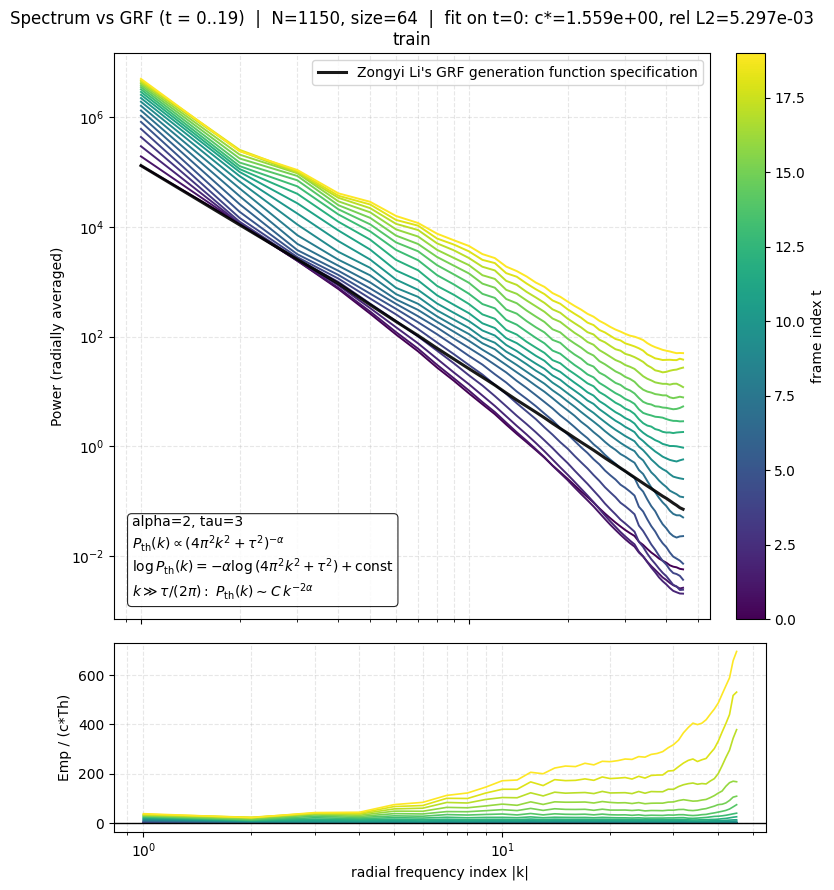

In [17]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_train_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

In [18]:
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import torch
import matplotlib.pyplot as plt

def verify_spectrum_trends(
    pt_path,
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None, batch_size=64, device="cpu",
    kmin=1, kmax=None, fft_norm="backward",
    frames=None,                 # 默认 0..19
    cmap_name="viridis",         # 渐变色
    reverse_cmap=False,          # 是否反转颜色方向（True=晚期深色，早期亮色）
    k_low_max="auto",            # 低频能量积分上限（整数或 "auto"）
    k_high_min="auto",           # 高频能量积分下限（整数或 "auto"）
    show_heatmap=True            # 是否画增长因子热图
):
    # ---- 载入数据
    pt_path = Path(pt_path)
    payload = torch.load(pt_path, map_location="cpu", weights_only=False)
    assert isinstance(payload, dict) and "y" in payload, f"{pt_path.name}: missing 'y'"
    y = payload["y"]
    assert torch.is_tensor(y) and y.ndim == 4, f"{pt_path.name}: y should be (N,H,W,T)"
    if y.dtype not in (torch.float32, torch.float64):
        y = y.float()
    N, H, W, T = map(int, y.shape)
    if max_samples is not None and max_samples < N:
        y = y[:int(max_samples)]
    N_use = y.shape[0]

    # ---- 帧序列
    if frames is None:
        frames = list(range(min(20, T)))
    else:
        frames = [t for t in frames if 0 <= t < T]
        if not frames:
            raise ValueError("frames is empty after clipping to [0, T-1].")
    t0 = frames[0]

    # ---- 理论谱 + t0 单次缩放
    k_th, P_th_raw = analytic_radial_psd(H, alpha=alpha, tau=tau, sigma=sigma, device=device)
    y_t0 = y[..., t0].contiguous()
    k_emp0, P_emp0 = empirical_radial_psd_from_y0(y_t0, batch_size=batch_size, device=device, fft_norm=fft_norm)
    if kmax is None:
        kmax = min(k_emp0[-1], k_th[-1])
    m = (k_emp0 >= kmin) & (k_emp0 <= kmax)
    Pe0 = torch.from_numpy(P_emp0[m]).to(torch.float64)
    Pt0 = torch.from_numpy(P_th_raw[m]).to(torch.float64)
    c_star0 = (Pe0 @ Pt0) / (Pt0 @ Pt0 + 1e-12)
    P_th = (c_star0.item() * P_th_raw)

    # ---- 分箱权重（用于能量积分）
    # 注意：经验谱是每个半径桶的平均功率，要恢复总能量需乘以桶内像元数
    _, _, ri_flat, counts = _kgrid_and_bins(H, device=device)
    counts_np = counts.cpu().numpy()
    R = counts_np.size
    k_idx = np.arange(R)

    # ---- 自动低/高频阈值
    if k_low_max == "auto":
        k_low_max = int(np.argmax(P_emp0))  # 注入附近
        k_low_max = max(kmin, k_low_max)
    if k_high_min == "auto":
        k_high_min = int(0.6 * kmax)

    # ---- 颜色映射
    norm = Normalize(vmin=min(frames), vmax=max(frames))
    cmap = cm.get_cmap(cmap_name)
    if reverse_cmap:
        cmap = cmap.reversed()

    # ---- 累积结果
    spectra = {}               # t -> (k, P_emp)
    E_total, E_low, E_high = [], [], []
    c_star_list = []           # 诊断：每帧的拟合系数（不用于主图缩放）

    # ---- 逐帧计算
    for t in frames:
        y_t = y[..., t].contiguous()
        k_emp, P_emp = empirical_radial_psd_from_y0(y_t, batch_size=batch_size, device=device, fft_norm=fft_norm)
        spectra[int(t)] = (k_emp, P_emp)

        # 能量积分（按桶像元数加权）
        P_full = np.asarray(P_emp)
        E_total.append( float((P_full[:R] * counts_np[:R]).sum()) )
        E_low  .append( float((P_full[kmin:min(k_low_max+1,R)] * counts_np[kmin:min(k_low_max+1,R)]).sum()) )
        E_high .append( float((P_full[max(k_high_min,0):R] * counts_np[max(k_high_min,0):R]).sum()) )

        # 诊断缩放：与未缩放理论谱在同一频段拟合
        Pe = torch.from_numpy(P_emp[m]).to(torch.float64)
        c_t = (Pe @ Pt0) / (Pt0 @ Pt0 + 1e-12)
        c_star_list.append(float(c_t.item()))

    # ---- 作图：三行
    fig, axs = plt.subplots(3, 1, figsize=(8.5, 11), sharex=False,
                            gridspec_kw={"height_ratios":[3,1.6,1.6]})

    # (1) 主图：多帧谱 + 单次缩放的理论谱
    for t in frames:
        k_emp, P_emp = spectra[int(t)]
        color = cmap(norm(t))
        axs[0].loglog(k_emp[m], P_emp[m], '-', lw=1.4, color=color)
    axs[0].loglog(k_th[m], P_th[m], '-', lw=2.2, color='k', alpha=0.9,
                  label="Zongyi Li's GRF generation function specification")
    sm = cm.ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs[0], fraction=0.046, pad=0.04)
    cbar.set_label("frame index t")
    axs[0].set_ylabel("Power (radially averaged)")
    axs[0].grid(True, which='both', ls='--', alpha=0.3)
    axs[0].legend(loc='best')
    axs[0].set_title(
        f"Spectrum (t={min(frames)}..{max(frames)}) | N={N_use}, size={H} | "
        f"fit on t={t0}: c*={c_star0.item():.3e}"
    )

    # (2) 能量随时间
    tt = np.array(frames, dtype=float)
    axs[1].plot(tt, E_total, '-', lw=1.8, label='Total energy')
    axs[1].plot(tt, E_low,   '--', lw=1.6, label=f'Low-k energy [k∈[{kmin},{k_low_max}]]')
    axs[1].plot(tt, E_high,  '-.', lw=1.6, label=f'High-k energy [k≥{k_high_min}]')
    axs[1].set_xlabel("frame index t")
    axs[1].set_ylabel("Integrated energy")
    axs[1].grid(True, ls='--', alpha=0.3)
    axs[1].legend(loc='best')
    axs[1].set_title("Energy growth/decay by bands (weighted by ring pixel counts)")

    # (3) 诊断缩放系数（不用于主图）：c*(t)/c*(t0)
    c_arr = np.array(c_star_list, dtype=float)
    axs[2].plot(tt, c_arr / c_arr[0], '-', lw=1.8)
    axs[2].axhline(1.0, color='k', lw=1)
    axs[2].set_xlabel("frame index t")
    axs[2].set_ylabel("c*(t) / c*(t0)")
    axs[2].grid(True, ls='--', alpha=0.3)
    axs[2].set_title("Diagnostic amplitude drift vs analytic GRF (same fit band)")

    plt.tight_layout()
    plt.show()

    # (4) 可选：增长因子热图（log-growth）
    if show_heatmap:
        # 组装矩阵：行=时间，列=径向 k
        K = m.sum()
        G = np.zeros((len(frames), K), dtype=np.float64)
        base = spectra[int(t0)][1][m] + 1e-30
        for i, t in enumerate(frames):
            G[i, :] = np.log( (spectra[int(t)][1][m] + 1e-30) / base )
        plt.figure(figsize=(8, 3.6))
        im = plt.imshow(G, aspect='auto', origin='lower',
                        extent=[k_emp0[m].min(), k_emp0[m].max(), frames[0], frames[-1]])
        plt.colorbar(im, fraction=0.046, pad=0.04, label="log growth vs t0")
        plt.xlabel("|k| (radial index)"); plt.ylabel("frame index t")
        plt.title("Log growth heatmap: log[P_emp(k,t)/P_emp(k,t0)]")
        plt.tight_layout(); plt.show()

    # 汇总结果
    return {
        "frames": frames,
        "k": k_emp0,
        "spectra": spectra,                # dict: t -> (k, P_emp)
        "P_th_scaled": P_th,
        "c_star_t0": float(c_star0.item()),
        "c_star_each": c_star_list,        # 诊断：每帧拟合（不用于主图）
        "E_total": E_total,
        "E_low": E_low,
        "E_high": E_high,
        "k_low_max": int(k_low_max),
        "k_high_min": int(k_high_min),
        "color_map_reversed": bool(reverse_cmap),
    }


/tmp/ipykernel_869198/957665441.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


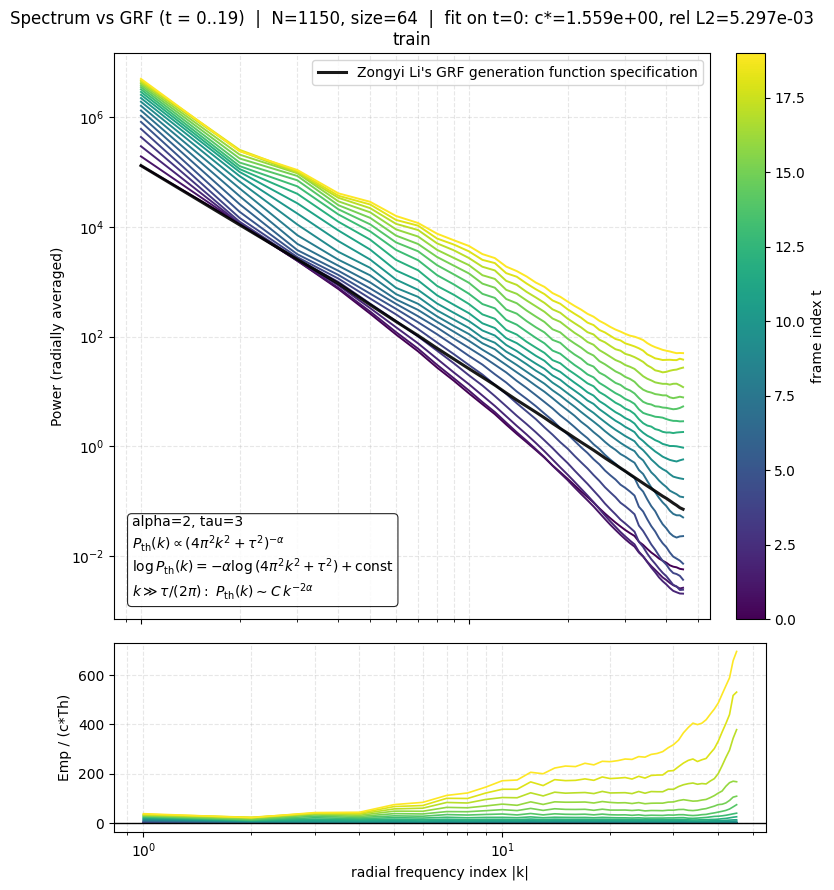

In [ ]:
res_train = compare_dataset_with_grf_spectrum(
    pt_path="NS_data_zongyi_train_all_frame.pt",
    alpha=2.0, tau=3.0, sigma=None,
    max_samples=None,        # 用全部样本；如需加速可设为 400 等
    batch_size=64,
    device="cpu",            # 如需 GPU 改成 "cuda"
    kmin=1, kmax=None,
    fft_norm="backward",
    label="train"
)

In [20]:
res_train

{'frames': [0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19],
 'k': array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
 'spectra': {0: (array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
          17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
          34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45]),
   array([1.80968455e-10, 1.30582532e+05, 1.14982932e+04, 2.40374146e+03,
          7.38178974e+02, 2.62375804e+02, 1.09179775e+02, 5.40609694e+01,
          2.73004660e+01, 1.57425691e+01, 9.30603867e+00, 5.87269875e+00,
          3.88147594e+00, 2.50373160e+00, 1.69329376e+00, 1.19842310e+00,
          8.60408924e-01, 6.25446256e-01, 4.50776474e-01, 3.40097104e-01,
          2.58384379e-01, 1.96907771e-01, 1.51750639e-01, 1.2006